## Probabilistic Modeling of A/B Compartments from E1

This model infers A/B chromatin compartment structure from the first eigenvector (E1) of the Hi-C contact matrix using a Bayesian framework.

### Goals
- Replace hard sign-thresholding of E1 with a probabilistic compartment assignment.
- Quantify uncertainty in compartment calls for each genomic bin.
- Allow for modeling of missing E1 values due to low signal.

### Assumptions
- Each bin belongs to one of two latent states: A or B compartment.
- E1 values are generated from Gaussian distributions specific to each compartment.
- Prior belief: A has positive E1 values (μ ≈ 0.5), B has negative (μ ≈ -0.5).
- Bins are initially treated as independent
- Spatial depency can be added later (HMM)


### The data

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from scipy.stats import norm


%config InlineBackend.figure_format = 'svg'



In [8]:


# Input: csv file with only the E1 columns

# Low res example
resolution = 100000

y = pd.Series(pd.read_csv(f"../data/eigs/fibroblast.eigs.{resolution}.cis.vecs.tsv", sep="\t")['E1'].values.flatten())
x = pd.Series(np.arange(0,y.shape[0])*resolution)

# Make a DataFrame object
df = pd.DataFrame({"start": x, "e1": y})

display(df)

,start,e1
0,0,NaN
1,100000,NaN
2,200000,NaN
3,300000,NaN
4,400000,NaN
...,...,...
1618,161800000,0.007641
1619,161900000,-0.026140
1620,162000000,-0.036445
1621,162100000,0.262607


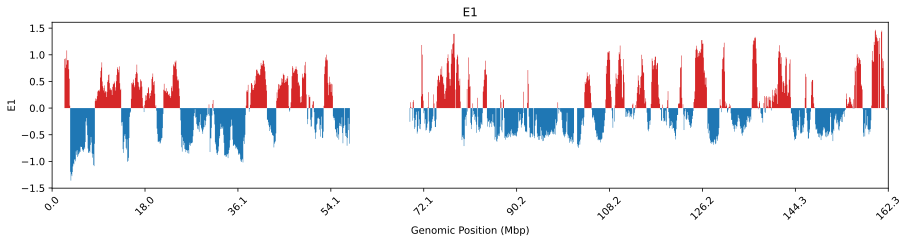

In [9]:
# Plot the data as a track (stairs for niceity)

fig, ax = plt.subplots(figsize=(15, 3))

x_stair = np.zeros(2*y.shape[0])
y_stair = np.zeros(2*y.shape[0])
x_stair[0::2] = x
x_stair[1::2] = x + resolution
y_stair[0::2] = y
y_stair[1::2] = y

ax.fill_between(x_stair, y_stair, where=(y_stair<0), color="tab:blue", ec='None')
ax.fill_between(x_stair, y_stair, where=(y_stair>0), color="tab:red", ec='None')

ax.set_xlim(0, df["start"].max()+resolution)
ticks = np.linspace(0, df["start"].max()+resolution, num=10)
ax.set_xticks(ticks)
ax.set_xticklabels(np.round(ticks / 1e6, 1), rotation=45)
ax.set_xlabel("Genomic Position (Mbp)")
ax.set_ylabel("E1")
ax.set_title("E1");

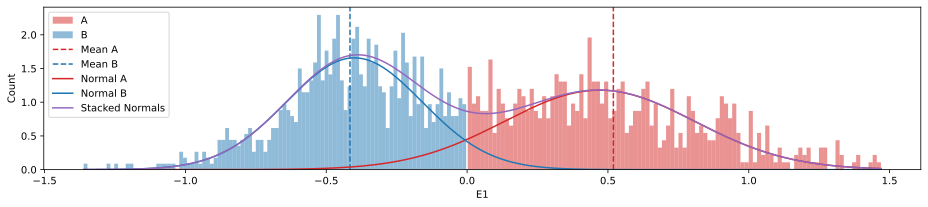

In [10]:
# Histogram of distribution of E1 values (A and B)

f, ax = plt.subplots(figsize=(13, 3))

# A compartments
ax.hist(y[y>0], bins=100, color="tab:red", alpha=0.5, label="A", density=True)
# B compartments
ax.hist(y[y<0], bins=100, color="tab:blue", alpha=0.5, label="B", density=True)
# Mean values (vline)
ax.axvline(y[y>0].mean(), color="tab:red", linestyle="--", label="Mean A")
ax.axvline(y[y<0].mean(), color="tab:blue", linestyle="--", label="Mean B")

# Plot the normal distributions
x_values = np.linspace(y.min(), y.max(), 1000)
mean_a = y[y>0].median()
mean_b = y[y<0].median()
std_a = y[y>0].std()
std_b = y[y<0].std()


ax.plot(x_values, norm.pdf(x_values, loc=mean_a, scale=std_a), color="tab:red", label="Normal A")
ax.plot(x_values, norm.pdf(x_values, loc=mean_b, scale=std_b), color="tab:blue", label="Normal B")
stacked = norm.pdf(x_values, loc=mean_a, scale=std_a) + norm.pdf(x_values, loc=mean_b, scale=std_b)
ax.plot(x_values, stacked, color="tab:purple", label="Stacked Normals")

plt.xlabel("E1")
plt.ylabel("Count")
plt.legend(loc='upper left')
plt.tight_layout()

### Model Specification

Before specifying the model, we need to layout the model structure. 

The model is a mixture of two Gaussian distributions, one for each compartment (A and B). Then a latent variable indicates the compartment assignment for each bin. The model. More formally;

#### Description

We aim to model the A/B chromatin compartments using a probabilistic generative approach, rather than relying on deterministic eigenvector sign thresholding. Each genomic bin is modeled as belonging to one of two latent states (A or B), with corresponding expected E1 values.


##### Notation

Let:

- $y_i$: Observed E1 value at bin $i$
- $ z_i \in \{0, 1\} $: Latent compartment assignment (0 = B, 1 = A)
- $ \mu_A, \mu_B $: Mean E1 values for compartments A and B
- $ \sigma $: Shared standard deviation across bins
- $ p $: Prior probability of a bin belonging to compartment A

##### Model variables

$$
\begin{aligned}
\mu_A &\sim \mathcal{N}(0.5, 0.5) \\
\mu_B &\sim \mathcal{N}(-0.5, 0.5) \\
\sigma &\sim \text{HalfNormal}(1) \\
p &\sim \text{Beta}(a, b) \quad \text{(e.g., } a = 2, b = 2 \text{ or something bimodal)} \\
z_i &\sim \text{Bernoulli}(p) \\
\mu_i &= z_i \cdot \mu_A + (1 - z_i) \cdot \mu_B \\
y_i &\sim \mathcal{N}(\mu_i, \sigma) \\
\end{aligned}
$$


This model allows us to infer both the compartment state and the uncertainty of the assignment, especially around boundaries between A and B compartments.




##### The Priors

- **$\mu_A$ and $\mu_B$**: We assume that the mean E1 values for compartments A and B are normally distributed around 0.5 and -0.5, respectively, with a standard deviation of 0.5. This reflects our prior belief about the expected E1 values for each compartment.
- **$\sigma$**: The standard deviation is modeled using a half-normal distribution, which ensures that it is always positive. This allows for flexibility in modeling the variability of E1 values within each compartment.
- **$p$**: The prior probability of a bin belonging to compartment A is modeled using a Beta distribution. This allows us to incorporate prior beliefs about the expected proportion of bins in each compartment. The parameters $a$ and $b$ can be adjusted to reflect different prior beliefs (e.g., bimodal distributions).
- **$z_i$**: The latent variable indicating the compartment assignment for each bin is modeled using a Bernoulli distribution, with the probability of being in compartment A given by $p$.
- **$y_i$**: The observed E1 values are modeled as normally distributed around the mean E1 value for the assigned compartment, with a shared standard deviation $\sigma$.
This generative model allows us to infer the compartment assignments and their associated uncertainties based on the observed E1 values, while also accounting for the variability in the data.

Let's look at a few different options for the Beta distribution. There are 3 main options:

- **Uniform**: $a = 1, b = 1$ (no prior preference for A or B)
- **Bimodal**: $a = 0.5, b = 0.5$ (most observations are certain to belong to A or B, but a few observations are hard to categorize—borders)
- **Unimodal**: $a = 2, b = 2$ (most obsevations are hard to categorize)

Here, they are visualized:

Sampling: [p]


Sampling: [p]
Sampling: [p]


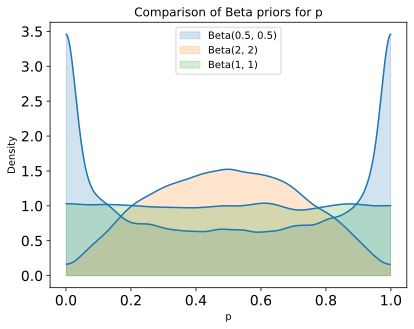

In [11]:
# First, have a look at different Beta distributions for the prior on the latent state (z)

fig, ax = plt.subplots()

params = [(0.5, 0.5), (2, 2), (1, 1)]
colors = ["tab:blue", "tab:orange", "tab:green"]

for (a, b),col in zip(params, colors):
    with pm.Model() as model:
        p = pm.Beta("p", alpha=a, beta=b)
        prior = pm.sample_prior_predictive(samples=10000)
        az.plot_kde(prior.prior["p"].values, label=f"Beta({a}, {b})", ax=ax, fill_kwargs={"alpha": 0.2, "color":col})

ax.set_title("Comparison of Beta priors for p")
ax.set_xlabel("p")
ax.set_ylabel("Density")
ax.legend()
plt.show()



~~I find that the most useful prior is the bimodal one, as we have a strong prior belief that most bins are either A or B, but a few bins are hard to categorize. This is especially useful for the edges of compartments, where the E1 values are close to 0. The unimodal prior is not very useful, as it assumes that most bins are hard to categorize, which is not the case in our data. The uniform prior could be useful as the most uninformative prior —the least biased.*~~

Above logic is flawed. This is not what the prior is reflecting. A Beta(0.5, 0.5) prior assumes that a data set is most likely consisting of only A or B compartments. Therefore, we need Beta(2,2) to reflect that compartments are expected to of both A and B. 

Sampling: [nu_exp, nu_norm]
Sampling: [nu_exp, nu_norm]
Sampling: [nu_exp, nu_norm]


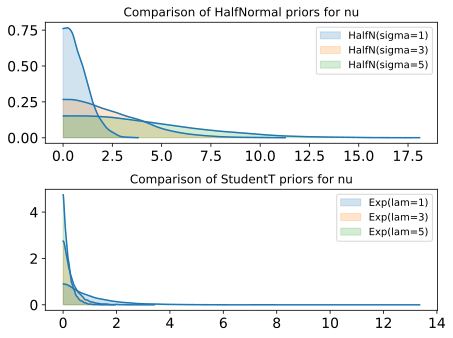

In [ ]:
fig, ax = plt.subplots((2))

#params = [(0.5, 0.5), (2, 2), (1, 1)]
params = [(1,0), (3,0), (5,0)]
colors = ["tab:blue", "tab:orange", "tab:green"]

for (a, b),col in zip(params, colors):
    with pm.Model() as ylik_priors:
        nu_norm = pm.HalfNormal("nu_norm", sigma=a)
        nu_exp = pm.Exponential("nu_exp", lam=a)
        prior = pm.sample_prior_predictive(samples=10000)
        ax[0].set_title("Comparison of HalfNormal priors for nu")
        az.plot_kde(prior.prior["nu_norm"].values, label=f"HalfN(sigma={a})", ax=ax[0], fill_kwargs={"alpha": 0.2, "color":col})
        ax[1].set_title("Comparison of Exponential priors for nu")
        az.plot_kde(prior.prior["nu_exp"].values, label=f"Exp(lam={a})", ax=ax[1], fill_kwargs={"alpha": 0.2, "color":col})

plt.tight_layout()

### Model in PyMC

In [14]:
coords = {"pos": x}

with pm.Model(coords=coords) as model:
    # Two means for A and B compartments
    mu_a = pm.Normal("mu_a", 0.5, 0.2)
    mu_b = pm.Normal("mu_b", -0.5, 0.2)

    # Standard deviation for the noise (only positive values HalfStudent)
    sigma = pm.HalfNormal("sigma", 0.3)

    # Latent state for each bin: 1 = A, 0 = B
    ## Prior belief: U-shaped distribution
    p = pm.Beta("p", 2, 2)  

    # Latent state variable z, indicating whether a bin is A or B
    z = pm.Bernoulli("z", p=p, dims="pos")

    # per-bin expected mean
    mu = pm.math.switch(z, mu_a, mu_b)

    # Likelihood
    # nu = pm.HalfNormal("nu", 5)  # Half-normal for the noise
    # y_lik = pm.StudentT("y_lik", mu=mu, sigma=sigma, nu=nu, observed=y) # It produced infinite values 
    y_lik = pm.Normal("y_lik", mu=mu, sigma=sigma, observed=y, dims="pos")


/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/pymc/model/core.py:1311: ImputationWarning: Data in y_lik contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)


#### Visual model

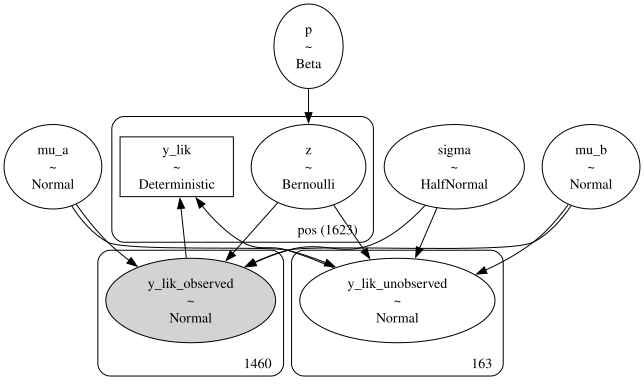

In [15]:
# Visualize
model_graph = pm.model_to_graphviz(model)
model_graph


#### Test the priors

In [16]:
with model:
    # Sample from the prior
    prior_samples = pm.sample_prior_predictive(samples=1000)

Sampling: [mu_a, mu_b, p, sigma, y_lik_observed, y_lik_unobserved, z]


In [17]:
prior_predictive_e1 = az.extract(prior_samples, group="prior", var_names=["y_lik"])

print(f"""
y_lik (min, max, std): {prior_predictive_e1.values.min(), prior_predictive_e1.values.max(), prior_predictive_e1.values.std()}
""")

#y_lik_norm (min, max, std): {prior_predictive_e1.y_lik_norm.values.min(), prior_predictive_e1.y_lik_norm.values.max(), prior_predictive_e1.y_lik_norm.values.std()}


y_lik (min, max, std): (np.float64(-4.023909132246375), np.float64(4.246997418429436), np.float64(0.612544822099371))



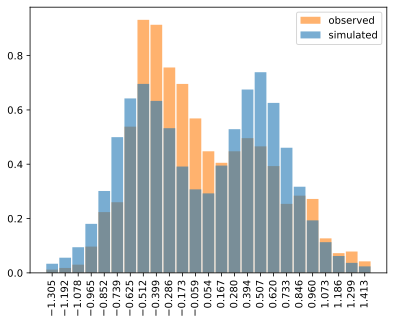

In [18]:
e1_obs = df['e1'].dropna().values

az.plot_dist(
    e1_obs,
    kind="hist",
    color="C1", 
    hist_kwargs={"alpha": 0.6,  "bins": 25},
    label="observed"
)



prior_pred_obs = prior_samples.prior_predictive["y_lik_observed"].stack(sample=("chain", "draw")).dropna("y_lik_observed_dim_0").values
prior_pred_obs = prior_pred_obs[prior_pred_obs > e1_obs.min()]  # Constrain the range to observed values
prior_pred_obs = prior_pred_obs[prior_pred_obs < e1_obs.max()]  # Constrain the range to observed values

az.plot_dist(
    prior_pred_obs,
    kind="hist",
    hist_kwargs={"alpha": 0.6, "bins":25},
    label="simulated",
)
plt.xticks(rotation=90);



~~This was quite involved to get to plot, as the prior predictions take values between -Inf and Inf. It could mean that the priors are not super robust to the random variables defining the StudentT draws from `y_lik`: If the `nu` or `sigma` draws are too small, the T-dist could become numerically unstable and produce Inf values.~~

With y_lik adhering to a Normal distribution, there are no infinites, and the range is more narrow. That must mean something to the predicitions as well, but I'm not quite sure about the effect. 

#### Posterior sampling

Here, we both create a trace (by sampling) and then sample from the predictive posterior. 

In [19]:
with model:
    # Sample from the posterior
    trace = pm.sample(2000, tune=2000, cores=8, chains=8, target_accept=0.90)

with model:
    pm.sample_posterior_predictive(trace, extend_inferencedata=True)

Multiprocess sampling (8 chains in 8 jobs)
CompoundStep
>NUTS: [mu_a, mu_b, sigma, p, y_lik_unobserved]
>BinaryGibbsMetropolis: [z]


Output()

Sampling 8 chains for 2_000 tune and 2_000 draw iterations (16_000 + 16_000 draws total) took 417 seconds.
/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Sampling: [y_lik_observed]


Output()

#### Evaluation 

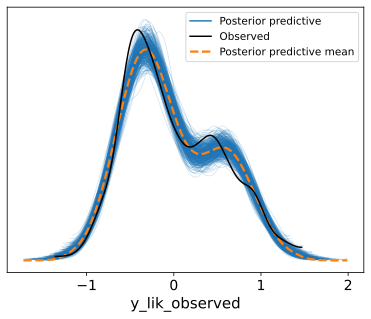

In [22]:
az.plot_ppc(trace, num_pp_samples=500);

> Slight deviation near 1 in the posterior predictive distribution suggests possible additional states, but the model otherwise captures the main features of the E1 distribution.

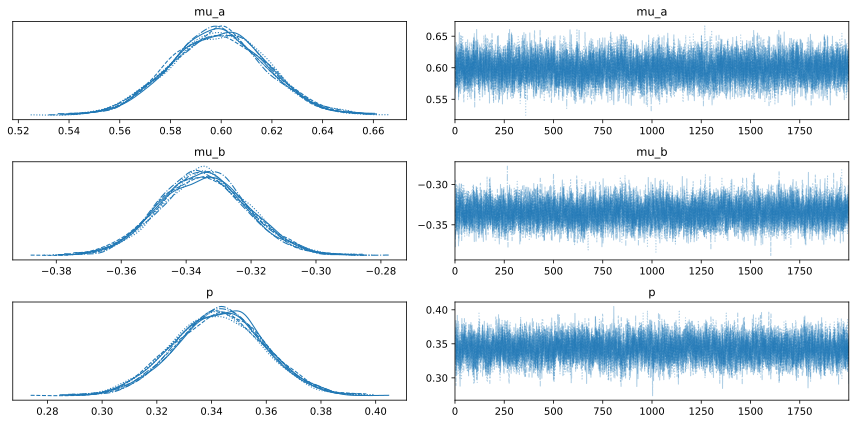

In [26]:
az.plot_trace(trace, var_names=["mu_a", "mu_b", "p"], compact=True, backend_kwargs={'layout': 'tight'});

In [27]:
trace_ylik = az.summary(trace, var_names=['y_lik'])


/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (b

In [28]:
trace_ylik


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
y_lik[0],-0.020,0.544,-0.882,1.016,0.011,0.004,3291.0,12260.0,1.0
y_lik[100000],-0.027,0.540,-0.898,0.986,0.011,0.004,3174.0,11442.0,1.0
y_lik[200000],-0.013,0.546,-0.894,1.018,0.010,0.003,3519.0,12495.0,1.0
y_lik[300000],-0.024,0.542,-0.863,1.027,0.011,0.004,3007.0,12660.0,1.0
y_lik[400000],-0.005,0.553,-0.876,1.028,0.011,0.004,3191.0,12118.0,1.0
...,...,...,...,...,...,...,...,...,...
y_lik[161800000],0.008,0.000,0.008,0.008,0.000,NaN,16000.0,16000.0,NaN
y_lik[161900000],-0.026,0.000,-0.026,-0.026,0.000,0.000,16000.0,16000.0,NaN
y_lik[162000000],-0.036,0.000,-0.036,-0.036,0.000,0.000,16000.0,16000.0,NaN
y_lik[162100000],0.263,0.000,0.263,0.263,0.000,0.000,16000.0,16000.0,NaN


ylik mean,sd of means: (np.float64(-0.015), np.float64(0.516))
ylik mean,sd of stds: (np.float64(0.055), np.float64(0.164))


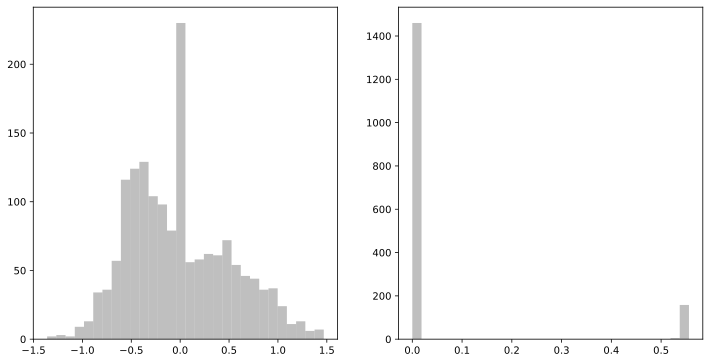

In [29]:

print(f"ylik mean,sd of means: {trace_ylik['mean'].mean().round(3), trace_ylik['mean'].std().round(3)}")
print(f"ylik mean,sd of stds: {trace_ylik['sd'].mean().round(3), trace_ylik['sd'].std().round(3)}")

f,ax = plt.subplots(1,2, figsize=(12, 6))
ax = ax.flatten()
ax[0].hist(trace_ylik['mean'], bins=30, color="tab:grey", alpha=0.5, label="Mean of y_lik");
ax[1].hist(trace_ylik['sd'], bins=30, color="tab:grey", alpha=0.5, label="SD of y_lik");

In [30]:
p_B = trace.posterior["z"].mean(dim=["chain", "draw"]).values
y_ppc = trace.posterior_predictive["y_lik"]

y_ppc_flat = y_ppc.stack(sample=("chain", "draw"))


ppc_mean = y_ppc_flat.mean(dim="sample").values       # mean of predictions per bin
ppc_std = y_ppc_flat.std(dim="sample").values         # predictive std (uncertainty)
ppc_hdi = az.hdi(y_ppc, hdi_prob=0.95)                # 95% HDI using ArviZ

## ppc_hdi.y_lik.sel(hdi='lower').values

# f,ax = plt.subplots(figsize=(10, 3))
# ax.plot(x,y_lik, color="tab:orange", alpha=0.6, lw=0.3, label="prediction confidence")
y_ppc

<xarray.DataArray 'y_lik' (chain: 8, draw: 2000, pos: 1623)> Size: 208MB
array([[[-8.27854742e-02, -4.10733874e-01, -3.32055598e-01, ...,
         -4.52088232e-01,  6.79722779e-01,  4.13900974e-01],
        [-2.31752785e-01, -2.46514569e-01, -2.84061646e-01, ...,
         -9.89408785e-02, -4.23953686e-01,  5.36982153e-01],
        [-4.46392833e-01, -4.07808627e-01, -3.01343621e-01, ...,
         -2.92662443e-01,  6.51893735e-01,  7.06459930e-01],
        ...,
        [ 6.18376401e-01,  2.03244766e-01, -1.89744228e-01, ...,
          2.57031130e-01, -2.84158088e-01,  1.57679782e-01],
        [ 5.28177803e-01, -6.24119247e-01, -3.78890145e-02, ...,
          1.14128282e-01,  1.13172620e-01, -5.81375779e-01],
        [ 5.40391225e-01,  2.05335201e-01, -6.03316110e-01, ...,
         -4.63263222e-01, -2.55367929e-01, -7.26723447e-02]],

       [[ 1.10776856e+00,  7.67308036e-01,  8.20445660e-01, ...,
         -2.75859278e-01, -5.26351916e-01,  9.30583624e-01],
        [ 9.22040025e-01,  8.04905817e-01,  5.93057736e-01, ...,
         -5.68253304e-01, -4.20901957e-02,  2.03696046e-01],
        [ 5.05849768e-01,  7.94664986e-01,  1.04512646e+00, ...,
         -6.29146581e-02,  3.72509320e-01, -2.04183309e-01],
...
          1.70636054e-02, -2.87937019e-01,  7.31961991e-02],
        [-5.17048056e-01, -4.98316388e-01,  4.34162779e-01, ...,
         -5.18453254e-01, -5.26478881e-01,  5.05988681e-01],
        [-1.27567980e-02,  1.00036702e-01,  8.17188977e-01, ...,
         -3.42525724e-01, -3.30406308e-01, -1.14491261e+00]],

       [[-1.47226255e-01, -5.86650967e-01, -9.64902026e-01, ...,
         -6.24025281e-01, -1.84658787e-01,  8.40059368e-01],
        [-4.99713416e-01, -7.15178449e-02,  3.38149843e-01, ...,
         -2.81818361e-01,  1.01872388e+00,  3.59894446e-01],
        [-1.27831054e-01,  1.19647837e+00,  8.23150867e-01, ...,
          8.60831117e-01,  5.53480506e-03, -9.48594967e-01],
        ...,
        [-6.13674904e-01, -4.45778400e-01,  1.86182864e-01, ...,
         -5.06043016e-01, -5.05158386e-02, -1.95842669e-01],
        [-5.45281449e-01, -4.88628071e-01, -3.88878730e-01, ...,
         -2.59523938e-01,  6.03377689e-01,  3.18948720e-01],
        [ 4.67685259e-02,  1.35273421e-02,  2.18608544e-02, ...,
          9.96565852e-02, -1.85274323e-01,  4.89965702e-01]]],
      shape=(8, 2000, 1623))
Coordinates:
  * chain    (chain) int64 64B 0 1 2 3 4 5 6 7
  * draw     (draw) int64 16kB 0 1 2 3 4 5 6 ... 1994 1995 1996 1997 1998 1999
  * pos      (pos) int64 13kB 0 100000 200000 ... 162000000 162100000 162200000

##### Posterior predictive checks

How does the posterior predictive look? We can visualize the distribution of predicted E1s based on the posterior samples. Here, the mean and sd of the posterior predictive for each bin are visualized in histograms.

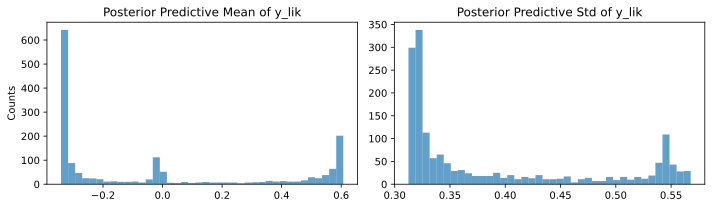

In [77]:
f,ax= plt.subplots(1,2, figsize=(10, 3))
ax[0].set_title("Posterior Predictive Mean of y_lik")
ax[0].set_ylabel("Counts")
ax[0].hist(ppc_mean, bins=40, alpha=0.7, label="Mean(y_lik)")
ax[1].set_title("Posterior Predictive Std of y_lik")
ax[1].hist(ppc_std, bins=40, alpha=0.7, label="Std(y_lik)")
plt.tight_layout()


##### Consistency

We can also try to calculate how consistent the predicted E1 is with the observed E1. Maybe this is useful.

In [ ]:
consistency = (np.sign(y_ppc_flat[100].values) == np.sign(p_B[100]) ).sum()/ y_ppc_flat.shape[1]
print(consistency,p_B[100])

0.8338125 0.34825


In [19]:
# y_ppc_flat: shape (samples, bins)
# p_B: shape (bins,) — assumed to be in [0, 1] as posterior mean of z

# Compute signs (1 for A, -1 for B)
sign_y = np.sign(y_ppc_flat.T.values)          # shape (samples, bins)
sign_z = np.sign(p_B - 0.5)                  # maps to -1 (B) or +1 (A), shape (bins,)

# Match shape for broadcasting
sign_z_broadcast = sign_z[None, :]           # shape (1, bins)

# Compare predictions: boolean matrix (samples, bins)
match = sign_y == sign_z_broadcast

# Fraction of matches per bin
consistency_per_bin = match.mean(axis=0)     # shape (bins,)


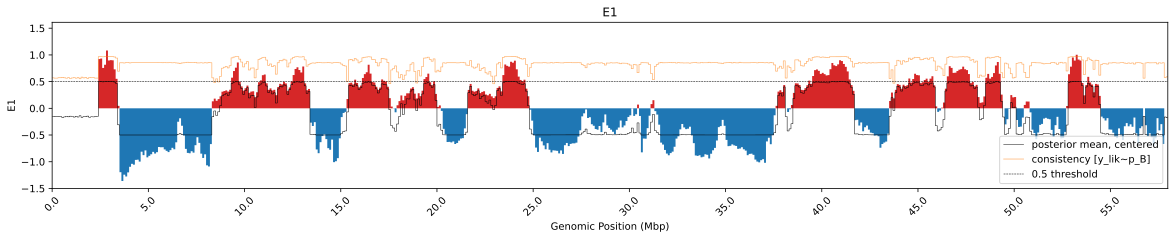

In [20]:
# Plot the data as a track (stairs for niceity)

fig, ax = plt.subplots(figsize=(20, 3))

# Stairs
x_stair = np.zeros(2*y.shape[0])
y_stair = np.zeros(2*y.shape[0])
x_stair[0::2] = x
x_stair[1::2] = x + resolution
y_stair[0::2] = y
y_stair[1::2] = y

ax.fill_between(x_stair, y_stair, where=(y_stair<0), color="tab:blue", ec='None')
ax.fill_between(x_stair, y_stair, where=(y_stair>0), color="tab:red", ec='None')

# Plot the posterior mean
post_mean_scaled = trace.posterior["z"].mean(dim=["chain", "draw"]).values-0.5
pms_stair = np.zeros(2*y.shape[0])
pms_stair[0::2] = post_mean_scaled
pms_stair[1::2] = post_mean_scaled
ax.plot(x_stair,pms_stair, color="k", label="posterior mean, centered", lw=0.5)

# Plot the confidence in the compartment call as a curve
conf_stair = np.zeros(2*y.shape[0])
conf_stair[0::2] = consistency_per_bin
conf_stair[1::2] = consistency_per_bin
ax.plot(x_stair,conf_stair, color="tab:orange", alpha=0.6, lw=0.7, label="consistency [y_lik~p_B]")
ax.hlines(0.5, xmin=0, xmax=x_stair.max(), color="k", linestyle="--", lw=0.5, label="0.5 threshold")

ax.set_xlim(0, 57_984_683)
ticks = np.arange(0, 57_984_683, step=5_000_000)
ax.set_xticks(ticks)
ax.set_xticklabels(np.round(ticks / 1e6, 2), rotation=45)
ax.set_xlabel("Genomic Position (Mbp)")
ax.set_ylabel("E1")
ax.set_title("E1")
ax.legend(loc="best");

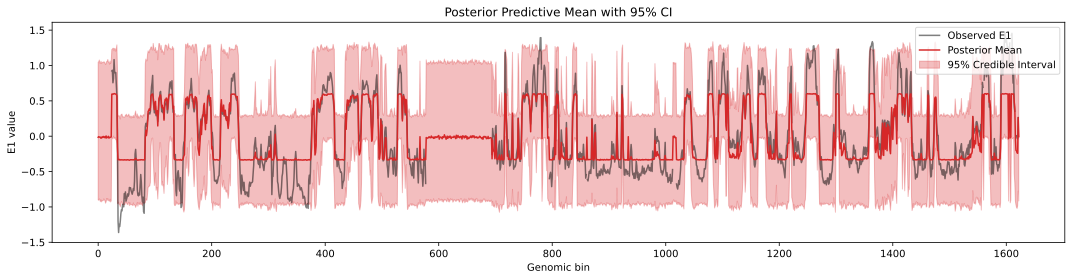

In [21]:
bins = np.arange(len(y))

plt.figure(figsize=(15, 4))

# Observed data
plt.plot(bins, y, label="Observed E1", color="black", alpha=0.5)

# Posterior predictive mean
plt.plot(bins, ppc_mean, label="Posterior Mean", color="tab:red")

# Credible interval shading
plt.fill_between(
    bins,
    ppc_hdi.y_lik.sel(hdi='lower').values,
    ppc_hdi.y_lik.sel(hdi='higher').values,
    color="tab:red",
    alpha=0.3,
    label="95% Credible Interval"
)

plt.xlabel("Genomic bin")
plt.ylabel("E1 value")
plt.title("Posterior Predictive Mean with 95% CI")
plt.legend()
plt.tight_layout()
plt.show()


### Convert the posterior into a confidence around the compartment borders

In [38]:
# Posterior mean of the latent state z
p_B = trace.posterior["z"].mean(dim=["chain", "draw"]).values

# Find boundaries
transitions = np.diff(p_B > 0.5).nonzero()[0] + 1  # +1 because np.diff reduces the length by 1
transitions *= resolution

transitions

array([  2400000,   3400000,   8700000,  13400000,  15400000,  17500000,
        18100000,  18200000,  18300000,  18900000,  19000000,  20000000,
        21600000,  22900000,  23000000,  24800000,  37700000,  38100000,
        38500000,  41700000,  43600000,  43700000,  43800000,  45900000,
        46400000,  48200000,  48400000,  49400000,  49800000,  50100000,
        52800000,  54500000,  71600000,  72000000,  73000000,  73100000,
        74000000,  74100000,  74700000,  76200000,  76300000,  78200000,
        78300000,  79200000,  80500000,  80600000,  80700000,  81200000,
        83600000,  84400000,  87000000,  87100000,  91400000,  91500000,
        92300000,  92500000, 103300000, 104600000, 107500000, 108600000,
       109300000, 110700000, 110800000, 111100000, 113500000, 115000000,
       116300000, 117700000, 119500000, 119600000, 121800000, 122200000,
       124700000, 127100000, 130000000, 130600000, 135900000, 136900000,
       138200000, 138300000, 138600000, 138700000, 

**Estimate uncertainty for each boundary:**

For each boundary at bin `i`, define a local window (±w bins), and compute where the transition probability is maximally uncertain (e.g., p ≈ 0.5):

In [28]:
z_samples = trace.posterior['z'].stack(sample=('chain', 'draw')).values

ci_lower = np.quantile(z_samples, 0.025, axis=1)
ci_upper = np.quantile(z_samples, 0.975, axis=1)

In [31]:
ci_lower

array([0., 0., 0., ..., 0., 0., 0.], shape=(1623,))

## Next up: Introducing dependency between bins

In the next [notebook]("03_PyMC_GRW_logit.ipynb"), we will implement a Gaussian Random Walk (GRW) model to introduce spatial dependency between bins. We will investigate how it affects smoothing and uncertainty in compartment assignment. 

We will update the model to 

\begin{aligned}
p_t &\sim \mathcal{N}(p_{t-1}, \sigma^2_{t-1}) \\
z_t &\sim \text{Bernoulli}(p_t) \\ \\
\mu_{z_t} &= z_t \cdot \mu_A + (1 - z_t) \cdot \mu_B \\
y_t &\sim \mathcal{N}(\mu_{z_t}, \sigma^2)
\end{aligned}